In [2]:
import pandas as pd
import matplotlib.pyplot as plt



In [4]:
# Load the dataset
df = pd.read_csv("Dataset .csv")



In [5]:
# Display the first 5 rows
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [6]:
# Check dataset shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

Rows: 9551
Columns: 21

Column Names:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']


In [7]:
# Calculate percentage of restaurants offering table booking
table_booking_percentage = (
    df["Has Table booking"].value_counts(normalize=True) * 100
)

# Calculate percentage of restaurants offering online delivery
online_delivery_percentage = (
    df["Has Online delivery"].value_counts(normalize=True) * 100
)

print("Table Booking:")
print(table_booking_percentage)

print("\nOnline Delivery:")
print(online_delivery_percentage)

Table Booking:
No     87.875615
Yes    12.124385
Name: Has Table booking, dtype: float64

Online Delivery:
No     74.337766
Yes    25.662234
Name: Has Online delivery, dtype: float64


In [8]:
# Extract percentages for a clean summary

table_booking_yes = (
    df["Has Table booking"].eq("Yes").mean() * 100
)

online_delivery_yes = (
    df["Has Online delivery"].eq("Yes").mean() * 100
)

print(f"Restaurants offering table booking: {table_booking_yes:.2f}%")
print(f"Restaurants offering online delivery: {online_delivery_yes:.2f}%")

Restaurants offering table booking: 12.12%
Restaurants offering online delivery: 25.66%


In [9]:
# Compare average ratings based on table booking

average_rating = df.groupby("Has Table booking")["Aggregate rating"].mean()

print("Average Rating by Table Booking:")
print(average_rating)

Average Rating by Table Booking:
Has Table booking
No     2.559359
Yes    3.441969
Name: Aggregate rating, dtype: float64


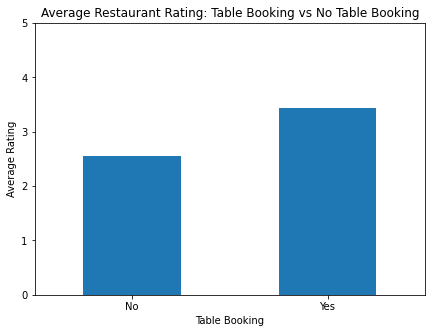

In [10]:
# Visualize average ratings

average_rating.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Restaurant Rating: Table Booking vs No Table Booking")
plt.xlabel("Table Booking")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)
plt.ylim(0, 5)
plt.show()

In [11]:
# Generate conclusion

with_booking = average_rating.get("Yes", 0)
without_booking = average_rating.get("No", 0)

print(f"Average rating with table booking: {with_booking:.2f}")
print(f"Average rating without table booking: {without_booking:.2f}")

if with_booking > without_booking:
    print("\nConclusion: Restaurants offering table booking have a higher average rating.")
elif with_booking < without_booking:
    print("\nConclusion: Restaurants without table booking have a higher average rating.")
else:
    print("\nConclusion: Both groups have the same average rating.")

Average rating with table booking: 3.44
Average rating without table booking: 2.56

Conclusion: Restaurants offering table booking have a higher average rating.


In [12]:
# Analyze online delivery availability across different price ranges

delivery_by_price = pd.crosstab(
    df["Price range"],
    df["Has Online delivery"],
    normalize="index"
) * 100

print("Online Delivery Availability by Price Range (%):")
print(delivery_by_price.round(2))

Online Delivery Availability by Price Range (%):
Has Online delivery     No    Yes
Price range                      
1                    84.23  15.77
2                    58.69  41.31
3                    70.81  29.19
4                    90.96   9.04


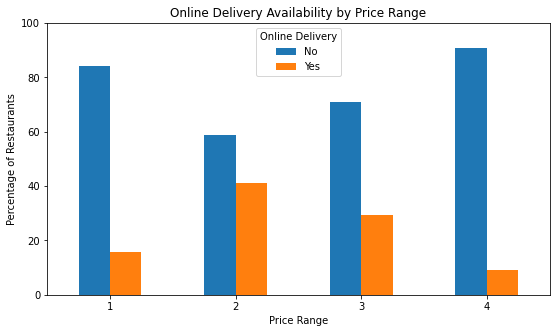

In [13]:
# Visualize online delivery availability by price range

delivery_by_price.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Online Delivery Availability by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Percentage of Restaurants")
plt.xticks(rotation=0)
plt.legend(title="Online Delivery")
plt.ylim(0, 100)
plt.show()


In [14]:
# Find the percentage of restaurants offering online delivery
# in each price range

delivery_yes = delivery_by_price["Yes"]

print("Online Delivery Percentage by Price Range:")
for price_range, percentage in delivery_yes.items():
    print(f"Price Range {price_range}: {percentage:.2f}%")

highest_delivery_range = delivery_yes.idxmax()
highest_delivery_percentage = delivery_yes.max()

print(
    f"\nHighest online delivery availability: "
    f"Price Range {highest_delivery_range} "
    f"({highest_delivery_percentage:.2f}%)"
)

Online Delivery Percentage by Price Range:
Price Range 1: 15.77%
Price Range 2: 41.31%
Price Range 3: 29.19%
Price Range 4: 9.04%

Highest online delivery availability: Price Range 2 (41.31%)
